<a href="https://colab.research.google.com/github/mohan0907-lab/project/blob/main/Data_Science_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Title : Flight Price Prediction

Import all the required libraries

In [ ]:
#import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [ ]:
#mount the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [74]:
#Load the dataset
df = pd.read_csv('/content/drive/MyDrive/project_dataset.csv', encoding='latin1')

Explore Data Analysis

In [75]:
#explore the dataset
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
# Separate the dataset based on 'class' column
economy_df = df[df['class'] == 'Economy']
business_df = df[df['class'] == 'Business']

print("Economy class shape:", economy_df.shape)
print("Business class shape:", business_df.shape)


Economy class shape: (206666, 12)
Business class shape: (93487, 12)


In [ ]:
economy_df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
business_df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
206666,206666,Air_India,AI-868,Delhi,Evening,zero,Evening,Mumbai,Business,2.00,1,25612
206667,206667,Air_India,AI-624,Delhi,Evening,zero,Night,Mumbai,Business,2.25,1,25612
206668,206668,Air_India,AI-531,Delhi,Evening,one,Night,Mumbai,Business,24.75,1,42220
206669,206669,Air_India,AI-839,Delhi,Night,one,Night,Mumbai,Business,26.50,1,44450
206670,206670,Air_India,AI-544,Delhi,Evening,one,Night,Mumbai,Business,6.67,1,46690


In [ ]:
#describe
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [ ]:
#find missing values
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [ ]:
#handle the missing values
df.dropna(inplace = True)


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [ ]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
df.tail()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [ ]:
#data types
df.dtypes

,0
Unnamed: 0,int64
airline,object
flight,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64


In [ ]:
#removing the unnecessary columns
df = df.drop(columns=['Unnamed: 0'])

In [76]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


EXPLORATORY DATA ANALYSIS

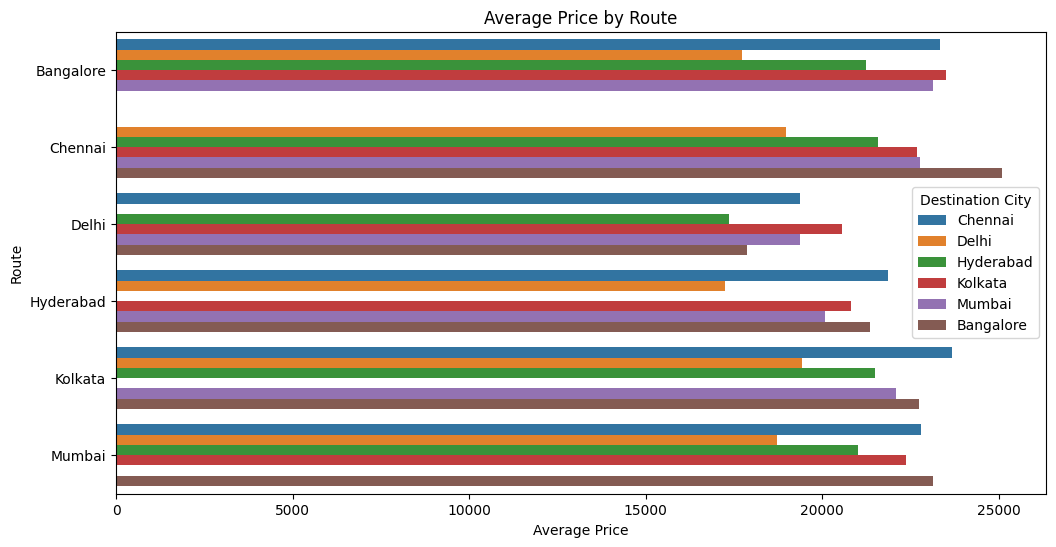

In [78]:
#Bar plot for Average price by Route
plt.figure(figsize=(12,6))
route_prices = df.groupby(['source_city','destination_city'])['price'].mean().reset_index()
sns.barplot(x='price', y='source_city', hue='destination_city', data=route_prices)
plt.title("Average Price by Route")
plt.xlabel("Average Price")
plt.ylabel("Route")
plt.legend(title='Destination City')
plt.show()


Text(0, 0.5, 'Price (Rupees)')

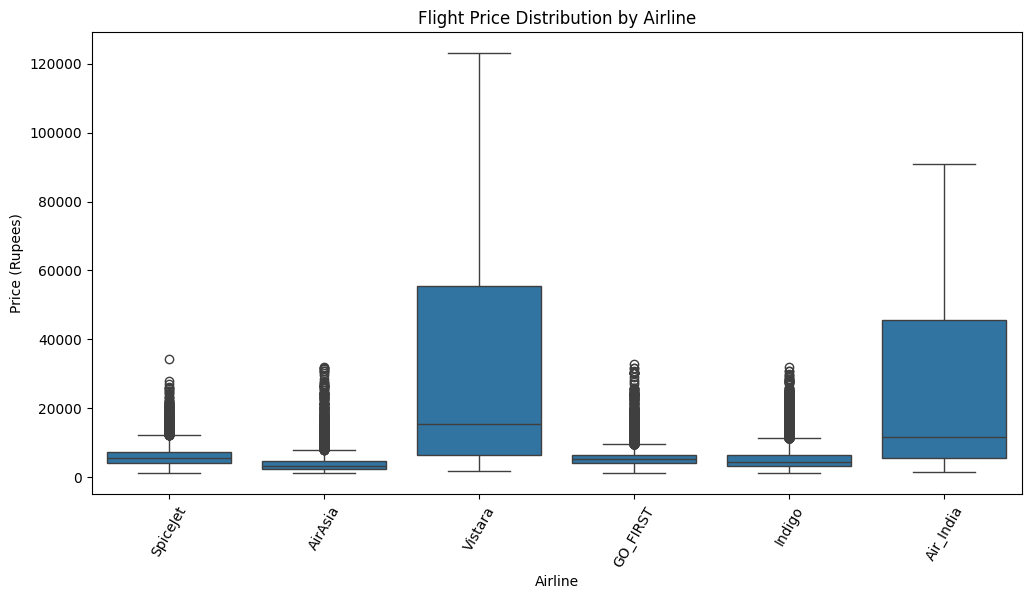

In [81]:

plt.figure(figsize=(12,6))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=60)
plt.title("Flight Price Distribution by Airline")
plt.xlabel("Airline")
plt.ylabel("Price (Rupees)")



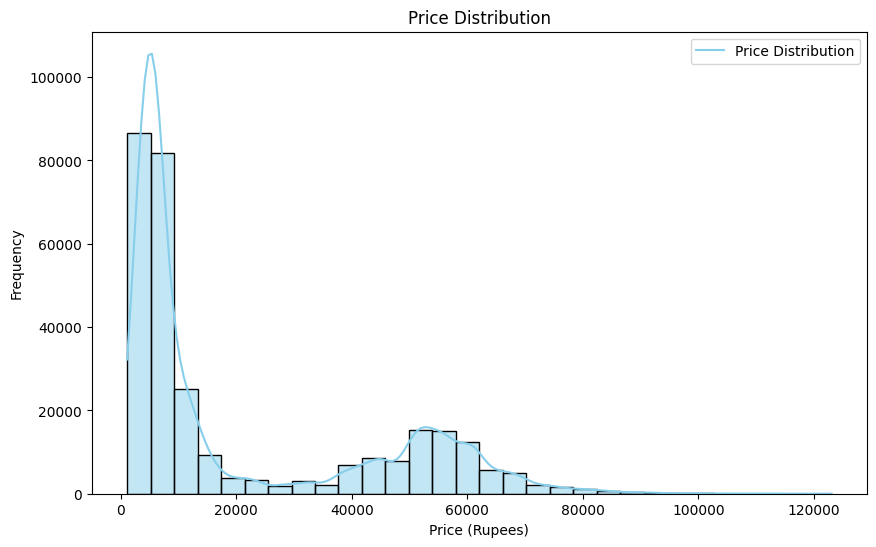

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=30, kde=True, color='skyblue')
plt.title("Price Distribution")
plt.xlabel("Price (Rupees)")
plt.ylabel("Frequency")
plt.legend(['Price Distribution'])
plt.show()


/tmp/ipython-input-795855800.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='airline', data=df, order=df['airline'].value_counts().index, palette='colorblind')


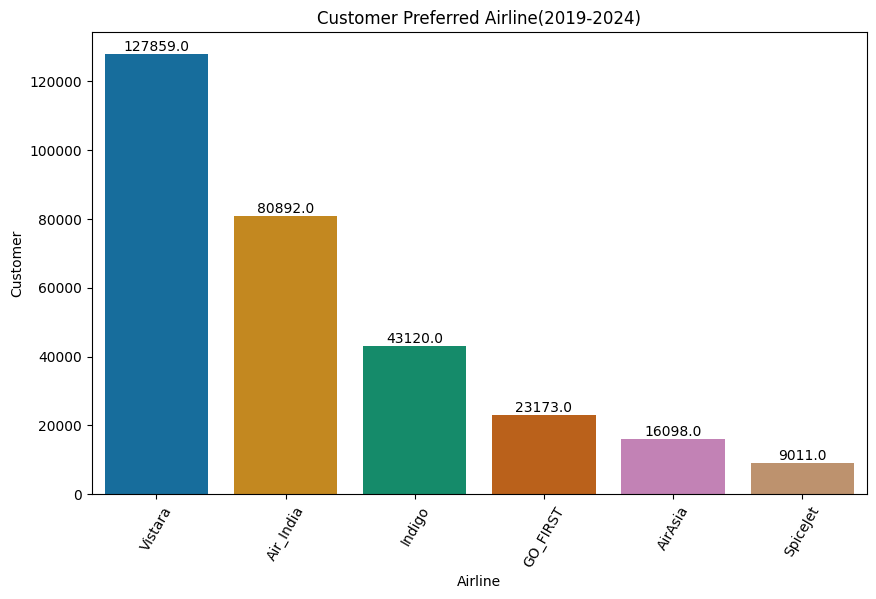

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x='airline', data=df, order=df['airline'].value_counts().index, palette='colorblind')
plt.xticks(rotation=60)
plt.title("Customer Preferred Airline(2019-2024)")
plt.xlabel("Airline")
plt.ylabel("Customer")

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

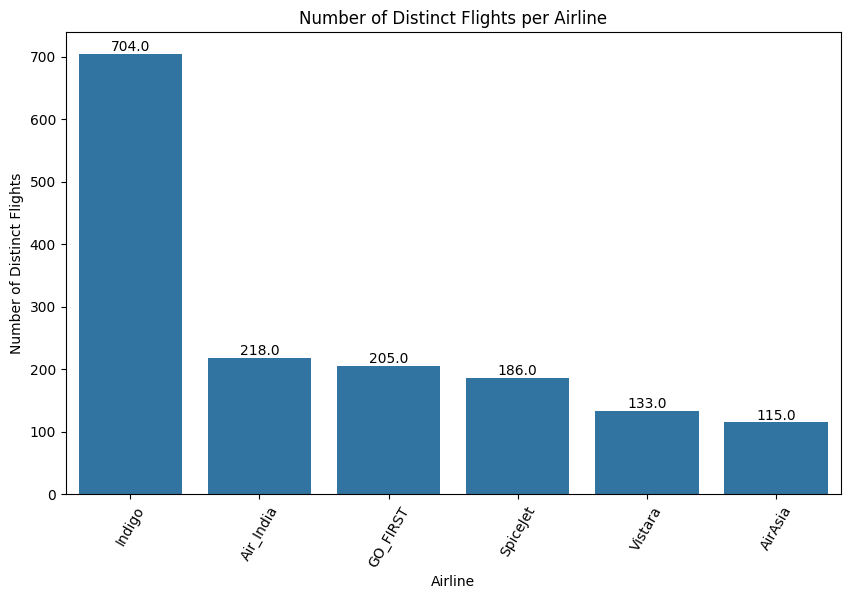

In [83]:
plt.figure(figsize=(10,6))
# Count distinct flight values for each airline
flight_counts = df.groupby('airline')['flight'].nunique().sort_values(ascending=False)
ax = sns.barplot(x=flight_counts.index, y=flight_counts.values)
plt.xticks(rotation=60)
plt.title("Number of Distinct Flights per Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Distinct Flights")

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

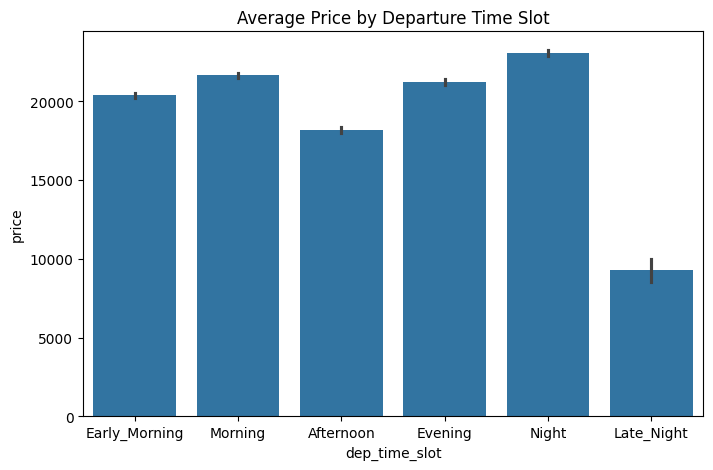

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a mapping from existing departure time strings to desired time slots
time_slot_mapping = {
    'Early_Morning': 'Early_Morning',
    'Morning': 'Morning',
    'Afternoon': 'Afternoon',
    'Evening': 'Evening',
    'Night': 'Night',
    'Late_Night': 'Late_Night'
}

# Apply the mapping to create the 'dep_time_slot' column
df['dep_time_slot'] = df['departure_time'].map(time_slot_mapping)

plt.figure(figsize=(8,5))
sns.barplot(x='dep_time_slot', y='price', data=df, order=['Early_Morning','Morning','Afternoon','Evening','Night', 'Late_Night'])
plt.title("Average Price by Departure Time Slot")
plt.show()

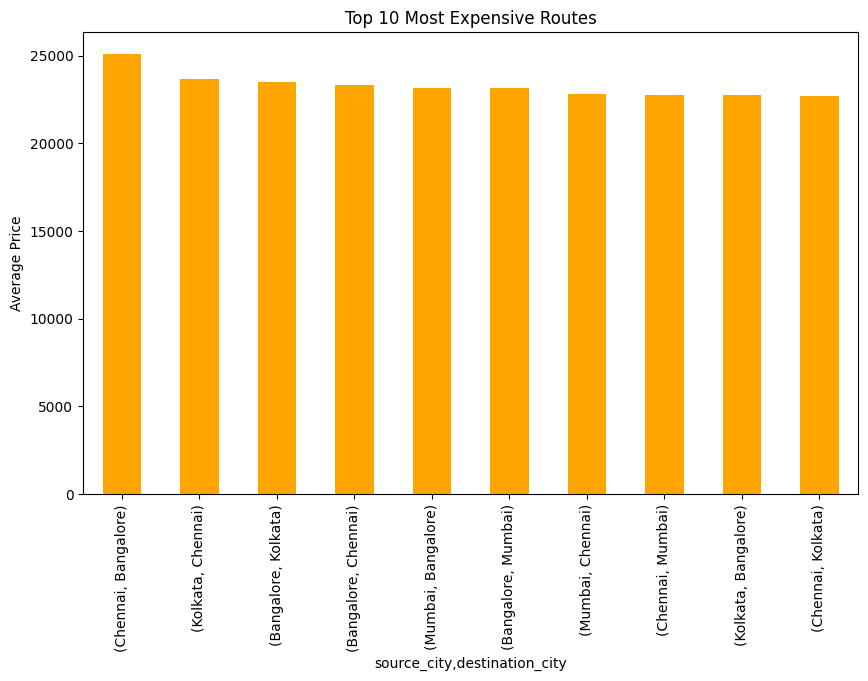

In [ ]:
top_routes = df.groupby(['source_city','destination_city'])['price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top_routes.plot(kind='bar', color='orange')
plt.title("Top 10 Most Expensive Routes")
plt.ylabel("Average Price")
plt.show()


#FEATURE ENGINEERING

In [ ]:
#Feature scaling
from sklearn.preprocessing import MinMaxScaler
#select numerical columns for scalimg
numerical_cols = df.select_dtypes(include=np.number).columns
#apply minmax scaler only to numerical columns
scaler = MinMaxScaler(feature_range=(0, 1))
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [ ]:
#Encode categorical variables using Label Encoding
from sklearn.preprocessing import LabelEncoder
cat_columns = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
# Import required libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np # Import nump

In [ ]:
# Split the data into features and target
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
X

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,dep_time_slot
0,4,1408,2,2,2,5,5,1,0.027347,0.0,2
1,4,1387,2,1,2,4,5,1,0.030612,0.0,1
2,0,1213,2,1,2,1,5,1,0.027347,0.0,1
3,5,1559,2,4,2,0,5,1,0.028980,0.0,4
4,5,1549,2,4,2,4,5,1,0.030612,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...
300148,5,1477,1,4,0,2,3,0,0.188776,1.0,4
300149,5,1481,1,0,0,5,3,0,0.195714,1.0,0
300150,5,1486,1,1,0,5,3,0,0.265306,1.0,1
300151,5,1483,1,1,0,2,3,0,0.187143,1.0,1


In [ ]:
y

,price
0,0.039749
1,0.039749
2,0.039773
3,0.039765
4,0.039765
...,...
300148,0.558844
300149,0.623124
300150,0.639473
300151,0.659856


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=26)

In [ ]:
X_train  = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
rf = RandomForestRegressor(n_estimators=125, random_state=26)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=125, random_state=26)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("Random Forest Performance:")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Random Forest Performance:
MSE: 0.0003
R² Score: 0.9899


In [ ]:
#hyper parameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [75, 125],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}
rf = RandomForestRegressor(random_state=26)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=26), n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'min_samples_split': [2, 5],
                         'n_estimators': [75, 125]},
             verbose=2)

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
print("MSE:", mean_squared_error(y_test, grid_search.predict(X_test)))

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 125}
Best Score: 0.989041712736592
MSE: 0.00034693043452233897


In [ ]:
#train model with xgboost
import xgboost as xgb
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=26)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#print results
y_pred = xgb_model.predict(X_test)

In [ ]:
#print results
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("XGBoost Performance:")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

XGBoost Performance:
MSE: 0.0003
R² Score: 0.9829


In [ ]:
#print results
print("XGBoost Performance:")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

XGBoost Performance:
MAE: 0.01
R² Score: 0.9829


In [84]:
# Linear Regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"MSE: {mse_lr:.4f}")
print(f"R² Score: {r2_lr:.4f}")

Linear Regression Performance:
MSE: 0.0033
R² Score: 0.9057


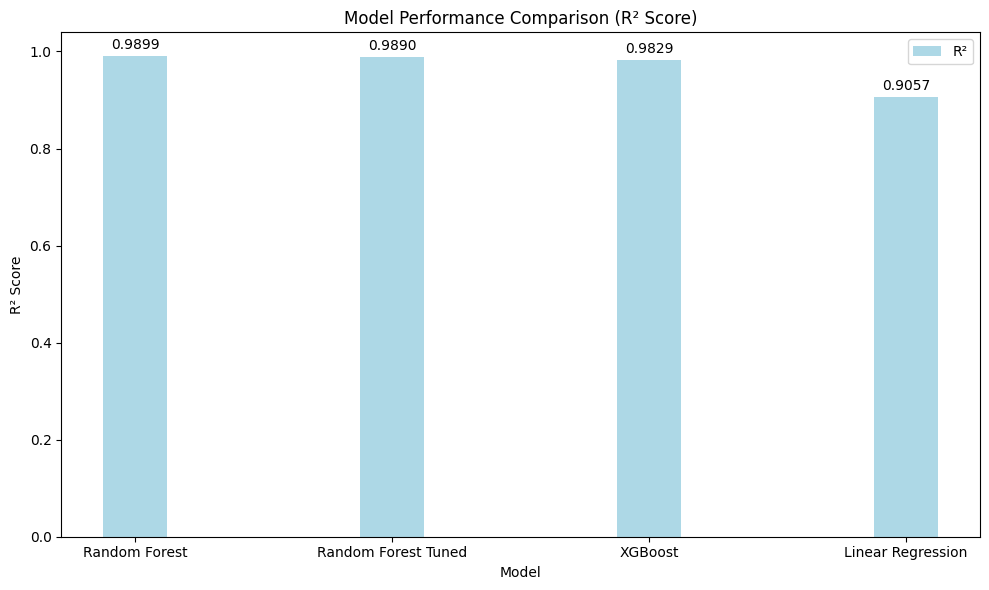

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# Data
model_names = ['Random Forest', 'Random Forest Tuned','XGBoost', 'Linear Regression']
mse = [0.0003, 0.0003, 0.0003, 0.0033]
r2 = [0.9899, 0.9890, 0.9829, 0.9057]

# Bar settings
x = np.arange(len(model_names))
width = 0.25

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(x, r2, width, label='R²', color = 'lightblue')


ax.bar_label(bars, fmt='%.4f', padding=3)


# Labels and title
ax.set_xlabel('Model')
ax.set_ylabel('R² Score')
ax.set_title('Model Performance Comparison (R² Score)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()


# Layout
plt.tight_layout()
plt.show()

Validation

In [ ]:
val_data = df.head(1000)

In [ ]:
val_data

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,dep_time_slot
0,4,1408,2,2,2,5,5,1,0.027347,0.000,0.039749,2
1,4,1387,2,1,2,4,5,1,0.030612,0.000,0.039749,1
2,0,1213,2,1,2,1,5,1,0.027347,0.000,0.039773,1
3,5,1559,2,4,2,0,5,1,0.028980,0.000,0.039765,4
4,5,1549,2,4,2,4,5,1,0.030612,0.000,0.039765,4
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,730,2,1,0,5,5,1,0.346939,0.125,0.064731,1
996,1,892,2,2,0,0,5,1,0.408163,0.125,0.065166,2
997,3,204,2,5,0,4,5,1,0.195714,0.125,0.066887,5
998,1,758,2,2,0,5,5,1,0.488163,0.125,0.067314,2


In [ ]:
X_val = val_data.drop('price', axis=1)
y_val = val_data['price']

X_val = scaler.transform(X_val)

In [60]:
y_val_pred = rf.predict(X_val)

print("MSE:" , mean_squared_error(y_val, y_val_pred))
print("R2:" , r2_score(y_val, y_val_pred))

MSE: 0.00014875336969563752
R2: 0.907580430997117


In [63]:
y_val_pred = grid_search.predict(X_val)

print("MSE:" , mean_squared_error(y_val, y_val_pred))
print("R2:" , r2_score(y_val, y_val_pred))

MSE: 0.0002212676894722145
R2: 0.8625277226517476


In [61]:
y_val_pred = xgb_model.predict(X_val)

print("MSE:" , mean_squared_error(y_val, y_val_pred))
print("R2:" , r2_score(y_val, y_val_pred))

MSE: 0.0005548577506719422
R2: 0.6552702350210096


In [62]:
y_val_pred = lr.predict(X_val)

print("MSE:" , mean_squared_error(y_val, y_val_pred))
print("R2:" , r2_score(y_val, y_val_pred))

MSE: 0.002566748896329159
R2: -0.5947055668233601


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


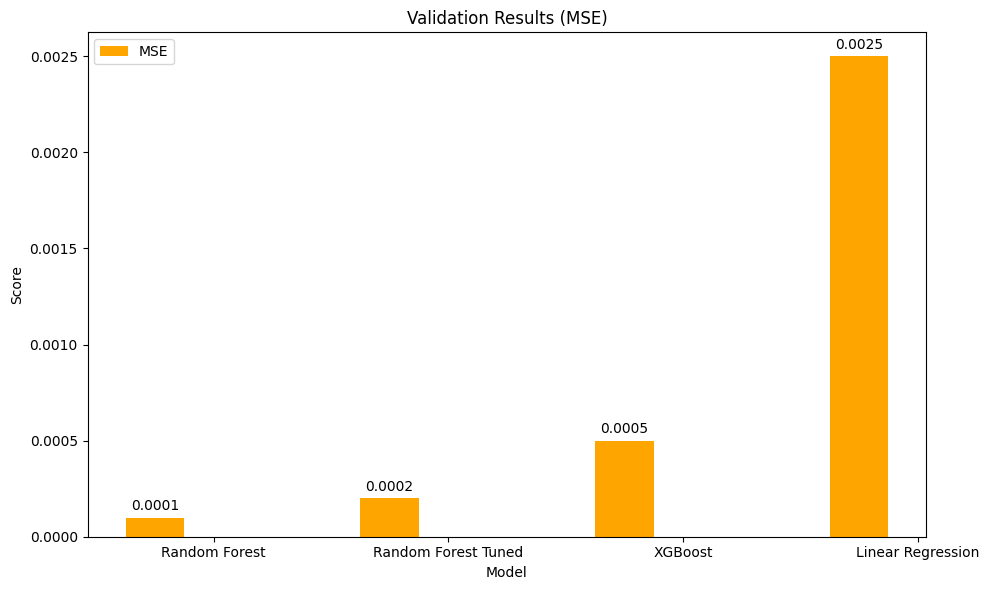

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Data
model_names = ['Random Forest','Random Forest Tuned', 'XGBoost', 'Linear Regression']
mse = [0.0001, 0.0002, 0.0005, 0.0025]
r2 = [0.9067, 0.8625, 0.6552, -0.5947]

# Bar settings
x = np.arange(len(model_names))
width = 0.25

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, mse, width, label='MSE', color = 'orange')

# Add value labels on top of the bars
ax.bar_label(bars1, fmt='%.4f', padding=3)


# Labels and title
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Validation Results (MSE)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()


# Layout
plt.tight_layout()
plt.show()



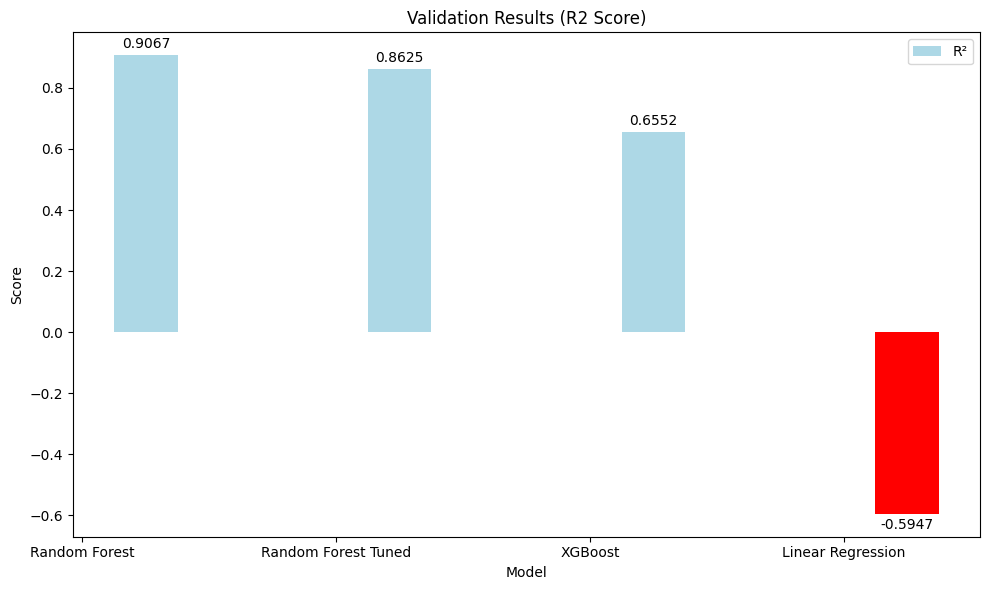

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Data
model_names = ['Random Forest','Random Forest Tuned', 'XGBoost', 'Linear Regression']
mse = [0.0001, 0.0002, 0.0005, 0.0025]
r2 = [0.9067, 0.8625, 0.6552, -0.5947]

# Bar settings
x = np.arange(len(model_names))
width = 0.25

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors for each bar
colors = ['lightblue', 'lightblue','lightblue','red']
bars3 = ax.bar(x + width, r2, width, label='R²', color = colors)

ax.bar_label(bars3, fmt='%.4f', padding=3)



# Labels and title
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Validation Results (R2 Score)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()


# Layout
plt.tight_layout()
plt.show()